# Building block — Adaptive N-AFC staircase — configured by one file

> **Building block.** A minimal, copy-pasteable block (config explanation +
> run + save) and nothing else. Paste it together with other blocks — e.g.
> `building_block_consent.ipynb` to get a `participant_id` — to assemble your
> own experiment notebook.


An **adaptive staircase** repeatedly presents an N-AFC trial, making the task
harder after correct answers and easier after wrong ones, so it homes in on the
participant's **threshold**.

To keep this simple, the **entire experiment is configured in a single file:**
[`configs/staircase_n_afc.yml`](../configs/staircase_n_afc.yml). The only thing
configured elsewhere is the shared look of the UIs
([`configs/design.yml`](../configs/design.yml)).

That one file is read by three consumers, each taking the keys it needs:

| block in the YAML | used by | configures |
|---|---|---|
| `SoundDevice:` | the audio handler | which WAV plays for each stimulus id |
| `test:` / `ui:` | the N-AFC window | #alternatives, shuffling, replay limit, window size, wording |
| `trial:` | this notebook | what one trial is (the odd-one-out design) |
| `staircase:` | this notebook | the adaptive rule |

**To design your own experiment, edit that YAML file** — you should not need to
change any Python below. If you haven't installed the project yet, run this
from the repo root: `pip install -e .`

In [10]:
import whispy
from pathlib import Path
from whispy.interfaces import SoundDevice
from whispy.ui import NAFC
from whispy.utils import read_config

config_path = Path('..') / 'configs' / 'staircase_n_afc.yml'  # <- the one file you edit
stimuli_dir = Path('demo_stimuli/staircase')                                 # <- folder with your WAVs

cfg = read_config(config_path)
handler = SoundDevice(config_path, stimuli_dir, loop=False)   # reads the SoundDevice: block
print('available stimulus ids:', list(handler.stimuli.keys()))

available stimulus ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## Using your own stimuli

The WAVs in `examples/demo_stimuli/staircase/` and the difficulty `levels` shipped in
the config are **only a demo**. For a real experiment you swap in your own sound
files — and you only touch the config and `stimuli_dir`, never the Python.

**1. Point `stimuli_dir` at your folder.** In the setup cell above, set it to
the folder holding your WAVs. A path relative to this notebook
(e.g. `Path('my_stimuli')`) or an absolute path both work.

**2. Map ids to files and pick your levels** in
[`configs/staircase_n_afc.yml`](../configs/staircase_n_afc.yml):

```yaml
SoundDevice:
  ref:   { file: reference.wav }       # the standard interval
  lvl_1: { file: target_hardest.wav }  # smallest difference -> hardest
  lvl_2: { file: target_medium.wav }
  lvl_3: { file: target_easiest.wav }  # largest difference -> easiest
trial:
  standard: ref                        # which id is the reference
  levels: [lvl_1, lvl_2, lvl_3]        # target ids, ordered hardest -> easiest
```

Ids can be any name (numbers or strings); they are written into your results, so
prefer descriptive ones. `test.n_choices` sets how many intervals per trial.

**Safety constraints** (checked automatically when the handler loads in the
setup cell — a violation raises a `ValueError`):

- **No clipping** — every sample must satisfy `|amplitude| < 1`. Leave headroom (e.g. normalise to ~0.7).
- **One sampling rate** — every file must share the same sampling rate; the handler uses it to configure playback.
- **All ids must exist** — every id in `trial.standard` / `trial.levels` must be defined under `SoundDevice:`.

Run the next cell to **pre-flight-check your files before testing a
participant**. After changing the config or `stimuli_dir`, re-run the setup cell
above so the handler reloads.

In [11]:
import numpy as np
import pyfar as pf

def check_stimuli(config_path, stimuli_dir):
    """Validate a stimulus set before running: existence, clipping, one
    sampling rate, and that every id used by the trial is defined."""
    cfg = read_config(config_path)
    sound = cfg.get('SoundDevice', {})
    trial = cfg.get('trial', {})
    folder = Path(stimuli_dir)

    problems, rates = [], {}
    print(f'Checking {len(sound)} stimuli in {folder.resolve()}\n')
    for sid, spec in sound.items():
        path = folder / spec['file']
        if not path.exists():
            problems.append(f"id {sid!r}: file not found -> {path}")
            print(f"  {str(sid):>8}  MISSING   {spec['file']}")
            continue
        sig = pf.io.read_audio(path)
        peak = float(np.max(np.abs(sig.time)))
        rates[sid] = sig.sampling_rate
        flag = '  <-- CLIPPING' if peak >= 1 else ''
        print(f"  {str(sid):>8}  {sig.sampling_rate} Hz  peak={peak:.3f}  {spec['file']}{flag}")
        if peak >= 1:
            problems.append(f"id {sid!r}: clips (peak={peak:.3f} >= 1)")

    for rid in [trial.get('standard'), *trial.get('levels', [])]:
        if rid not in sound:
            problems.append(f"trial uses id {rid!r}, but it is not defined under SoundDevice:")

    if len(set(rates.values())) > 1:
        problems.append(f"mixed sampling rates: {sorted(set(rates.values()))} (all must match)")

    print()
    if problems:
        print('NOT ready - fix these before running:')
        for prob in problems:
            print('  -', prob)
    else:
        print('All good: files exist, no clipping, one sampling rate, all trial ids defined.')
    return not problems

check_stimuli(config_path, stimuli_dir)

Checking 12 stimuli in D:\Uni\Sem IV\P&A\Whispy\whispy\examples\demo_stimuli\staircase

         1  44100 Hz  peak=0.700  stimulus_1.wav
         2  44100 Hz  peak=0.700  stimulus_2.wav
         3  44100 Hz  peak=0.700  stimulus_3.wav
         4  44100 Hz  peak=0.700  stimulus_4.wav
         5  44100 Hz  peak=0.700  stimulus_5.wav
         6  44100 Hz  peak=0.700  stimulus_6.wav
         7  44100 Hz  peak=0.700  stimulus_7.wav
         8  44100 Hz  peak=0.700  stimulus_8.wav
         9  44100 Hz  peak=0.700  stimulus_9.wav
        10  44100 Hz  peak=0.700  stimulus_10.wav
        11  44100 Hz  peak=0.700  stimulus_11.wav
        12  44100 Hz  peak=0.700  stimulus_12.wav

All good: files exist, no clipping, one sampling rate, all trial ids defined.


True

## The configuration

Open [`configs/staircase_n_afc.yml`](../configs/staircase_n_afc.yml) to see
every setting with inline comments. The cell below prints the parts that define
the experiment so you can see your current values at a glance.

Key things you'll typically change:

- **`trial.task`** — the prompt shown on top of the window.
- **`trial.standard` / `trial.levels`** — the reference stimulus and the target
  ids ordered *hardest → easiest*.
- **`test.n_choices`** — how many intervals per trial (the *N* in N-AFC).
- **`test.single_replay`** — if `true`, each interval can be heard at most
  twice (the first mandatory listen plus one replay); `false` allows unlimited
  replays.
- **`test.autoplay`** — if `true`, each trial starts by playing all intervals
  once in button order (this counts as the mandatory first listen);
  `test.autoplay_gap` is the pause between them in seconds.
- **`staircase.n_up` / `n_down`** — the adaptive rule (1-up/2-down ≈ 70.7%).
- **`staircase.max_reversals` / `max_trials`** — when the run stops.

In [12]:
print('test     :', cfg['test'])
print('ui       :', cfg['ui'])
print('trial    :', cfg['trial'])
print('staircase:', cfg['staircase'])

test     : {'n_choices': 3, 'shuffle_choices': True, 'single_replay': False, 'autoplay': False, 'autoplay_gap': 0.3}
ui       : {'content_top_share': 0.8, 'submit_hint_spacing': 45, 'submit_hint': 'Press the number keys (or click) to hear each interval, \n then press Enter to submit your choice.', 'submit_button_text': 'Submit choice', 'show_progress': True, 'progress_text': 'Trial {current} of {total}'}
trial    : {'task': 'Which interval is the **odd one out**?', 'standard': 1, 'levels': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'block_name': 'Staircase', 'section_name': '3-AFC'}
staircase: {'n_up': 1, 'n_down': 2, 'step': 1, 'start_index': -1, 'max_reversals': 6, 'max_trials': 20, 'reversals_for_threshold': 4}


## Wire the config to a staircase

These few lines just translate the config into a `build_screen(level)` callback
(which turns a difficulty level into an N-AFC trial) and a `whispy.Staircase`.
You normally don't edit this — it is driven entirely by the values above.

The trial is an **odd-one-out**: `n_choices - 1` intervals play the `standard`
and one plays the target `level` (the correct answer); `NAFC` shuffles the
buttons. The participant must listen to every interval before submitting.

In [13]:
trial = cfg['trial']
levels = trial['levels']
n_intervals = int(cfg['test']['n_choices'])

def build_screen(level):
    return {
        'test': [trial['standard']] * (n_intervals - 1) + [level],
        'correct': level,
        'task': trial['task'],
        'block': 0,
        'section': 0,
        'block_name': trial.get('block_name', 'Staircase'),
        'section_name': trial.get('section_name', 'N-AFC'),
    }

sc_kwargs = dict(cfg['staircase'])
if sc_kwargs.get('start_index', 0) < 0:          # allow -1 = easiest (last) level
    sc_kwargs['start_index'] += len(levels)

staircase = whispy.Staircase(levels, build_screen=build_screen, **sc_kwargs)
print('start level:', staircase.current_level, '| finished:', staircase.finished)

start level: 12 | finished: False


### What `build_screen` produces, and what one trial returns

Each call to `build_screen(level)` builds the `screen` dict that
`whispy.ui.NAFC` consumes — the same contract used for *any* N-AFC trial:

| key | meaning |
|---|---|
| `test` | list of stimulus ids, one per interval/button (length = `n_choices`) |
| `correct` | the id that counts as the correct answer |
| `task` | prompt shown on top of the N-AFC window (set inline on the screen) |
| `block`, `section`, `block_name`, `section_name` | metadata copied straight into the results |

For a single trial, `NAFC(screen=...).get_results()` returns a one-row
`DataFrame` with `choices` (the ids in the order shown), `selected`, `correct`,
`correct_bool`, `rt` (reaction time in seconds), plus that metadata. The
staircase calls `NAFC` once per trial and keeps only `correct_bool` to drive the
adaptive rule; the per-trial table further down is the staircase's own log.

## Validate your configuration without a GUI (dry run)

Run this **before** the live experiment below to sanity-check your
`staircase:` settings: it replaces the window with a simulated observer that
answers correctly with a per-level probability, then reports whether the run
converges and collects enough reversals/trials. Tune the YAML and re-run this
cell — no clicking required. (It reuses `cfg`, `levels` and `build_screen`
from the cells above, so run those first.)

In [14]:
import numpy as np

rng = np.random.default_rng(0)

# A simulated observer: probability of a correct response at each target
# level. Derived from your `levels` so it always covers every level no matter
# how many there are. `levels` is ordered hardest -> easiest, so accuracy
# ramps from just above chance (1/n_choices) up to near-certain. Replace this
# dict with your own numbers to model a specific listener.
chance = 1.0 / int(cfg['test']['n_choices'])
p_values = np.linspace(chance + 0.05, 0.98, len(levels))
p_correct = {level: float(p) for level, p in zip(levels, p_values)}

def simulated_trial(screen):
    return bool(rng.random() < p_correct[screen['correct']])

sim_kwargs = dict(cfg['staircase'])
if sim_kwargs.get('start_index', 0) < 0:
    sim_kwargs['start_index'] += len(levels)
sim = whispy.Staircase(levels, build_screen=build_screen, **sim_kwargs)

sim_results = sim.run(simulated_trial)
print('simulated p(correct):', {k: round(v, 2) for k, v in p_correct.items()})
print('simulated trials   :', len(sim_results))
print('simulated reversals:', sim.n_reversals)
print('simulated threshold:', sim.threshold())
sim_results

simulated p(correct): {2: 0.38, 3: 0.44, 4: 0.5, 5: 0.56, 6: 0.62, 7: 0.68, 8: 0.74, 9: 0.8, 10: 0.86, 11: 0.92, 12: 0.98}
simulated trials   : 19
simulated reversals: 6
simulated threshold: 9.5


,trial,level_index,level,correct,step,reversal
0,1,10,12,True,,False
1,2,10,12,True,down,False
2,3,9,11,True,,False
3,4,9,11,True,down,False
4,5,8,10,True,,False
5,6,8,10,False,up,True
6,7,9,11,True,,False
7,8,9,11,True,down,True
8,9,8,10,True,,False
9,10,8,10,False,up,True


## Run it

`staircase.run(run_trial)` drives the whole loop until it stops. `run_trial`
reuses **one window** for the entire experiment (the first trial opens it, later
trials swap their content into the same window via `parent=host`), so there is
no reload between trials and it stays fullscreen. The window is closed in a
`finally` block when the staircase finishes.

In each trial: click a button to hear that interval, listen to **all** of them,
select the odd one out, then press **Submit**.

In [15]:
host = None

def run_trial(screen):
    global host
    naf = NAFC(screen=screen, stimuli_handler=handler,
               n_afc_config=config_path, blocking=True, parent=host)
    if host is None:
        host = naf            # first trial owns the shared window
    return bool(naf.get_results()['correct_bool'].iloc[0])

try:
    results = staircase.run(run_trial)
finally:
    if host is not None:
        host.close()

results

,trial,level_index,level,correct,step,reversal
0,1,10,12,True,,False
1,2,10,12,True,down,False
2,3,9,11,True,,False
3,4,9,11,True,down,False
4,5,8,10,True,,False
5,6,8,10,False,up,True
6,7,9,11,False,up,False
7,8,10,12,False,up,False
8,9,10,12,True,,False
9,10,10,12,True,down,True


## Results & threshold

`staircase.get_results()` (returned above) has one row per trial: the level
presented, whether it was correct, the step taken, and whether it was a
reversal. `threshold()` averages the final reversal levels.

In [16]:
print('trials         :', len(results))
print('reversals      :', staircase.n_reversals)
print('reversal levels:', staircase.reversal_levels())
print('threshold      :', staircase.threshold())
results

trials         : 19
reversals      : 6
reversal levels: [10, 12, 11, 12, 11, 12]
threshold      : 11.5


,trial,level_index,level,correct,step,reversal
0,1,10,12,True,,False
1,2,10,12,True,down,False
2,3,9,11,True,,False
3,4,9,11,True,down,False
4,5,8,10,True,,False
5,6,8,10,False,up,True
6,7,9,11,False,up,False
7,8,10,12,False,up,False
8,9,10,12,True,,False
9,10,10,12,True,down,True


## Save the results

Save the results to a CSV in a `results/` folder (created next to this notebook).
The file name always carries a **timestamp**. If a `participant_id` is in scope
(set by a consent block earlier in the notebook) it is included
(`<name>_<id>_<timestamp>.csv`); otherwise an iterating fallback number is used
(`<name>_<NNN>_<timestamp>.csv`). Existing files are never overwritten.

In [17]:
from whispy.utils import save_results

# `participant_id` is picked up automatically if a consent block earlier in this
# notebook set it; otherwise it is None and the file name uses an iterating
# fallback number.
participant_id = globals().get('participant_id')
results_path = save_results(results, 'staircase_n_afc', participant_id=participant_id)
print('saved results to', results_path.resolve())

saved results to D:\Uni\Sem IV\P&A\Whispy\whispy\examples\results\staircase_n_afc_0006_20260703_195328.csv


## Plot the staircase

This plot shows the adaptive staircase over trials. Each point is the
level presented on that trial, the reversal points are highlighted
and the estimated threshhold is shown as a dashed line. It can be 
chosen how many of the last reversals are used for the estimate. By
default it will use all the reversals. Optionally an approximate 
target level based on the standard n-up/n_down rule can also be shown.

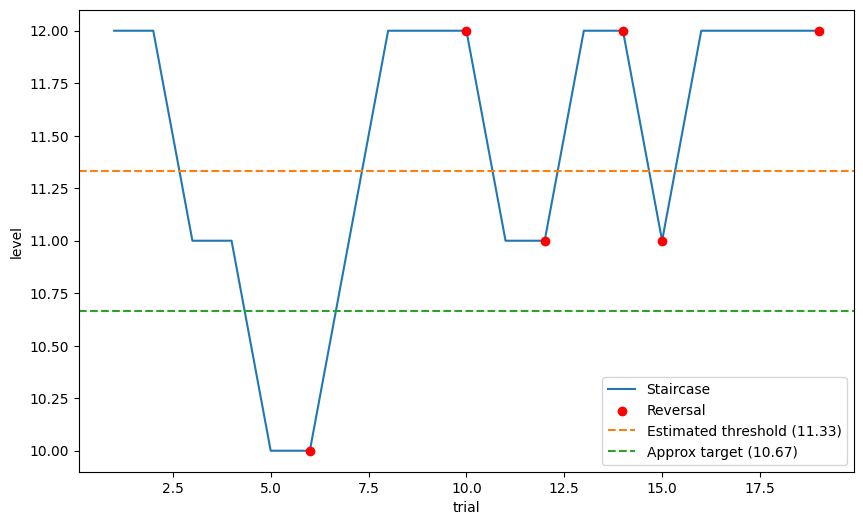

In [ ]:
from whispy.utils import plot_staircase

## Plot the staircase results
max_reversals = int(cfg['staircase']['max_reversals'])
plot_staircase(results, reversals_for_threshold=max_reversals)

## Plot with Approximate Target Level
# n_up = int(cfg['staircase']['n_up'])
# n_down = int(cfg['staircase']['n_down'])
# plot_staircase(results, reversals_for_threshold=max_reversals, n_up=n_up, n_down=n_down, show_approx_target=True)